In [12]:
# Import statements
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pk

In [13]:
# Special imports
import mlqmcpy as mp
from mlqmcpy.problems.elliptic import elliptic
from qmcpy import DigitalNetB2, Lattice

In [14]:
# Options
discrete_distribution_types = [Lattice, DigitalNetB2]
iterator_types = [mp.GreedyMLQMCIterator, mp.GreedyFastGaussianProcessMLQMCIterator]
num_repetitions = 10
m_range = range(2, 16)
num_levels = 4
num_dims = 8

In [15]:
# Get class basename as a str
def stringify(_class):
    return str(_class).split("'")[-2].split(".")[-1]

In [16]:
# Load
file_name = "error_estimates_elliptic_pde.pk"
if os.path.isfile(file_name):
    with open(file_name, "rb") as io:
        error_estimates = pk.load(io)
else:
    error_estimates = {}

In [17]:
# Compute error estimates
for discrete_distribution_type in discrete_distribution_types:
    for iterator_type in iterator_types:
        for level_num in range(num_levels):

            discrete_distribution_str = stringify(discrete_distribution_type)
            iterator_str = stringify(iterator_type)
            if (discrete_distribution_str, iterator_str, level_num) in error_estimates.keys():
                continue

            # Preallocate error estimates matrix
            error_estimates_mat = np.zeros((len(m_range), num_repetitions))

            for repetition in range(num_repetitions):
                for j, m in enumerate(m_range):

                    # Make iterator
                    max_budget = 2**m
                    iterator = iterator_type(
                        num_dims,  # Number of dimensions
                        initial_sample_size=max_budget,
                        max_budget=max_budget,
                        discrete_distribution_type=discrete_distribution_type
                    )

                    # Iterate
                    for iter, new_samples in enumerate(iterator):

                        # Solve the PDE
                        new_results = {
                            level: [elliptic.ml(level_num + level, sample) for sample in samples]
                            for level, samples in new_samples.items()
                        }

                        # Update the sampler with computed outputs
                        iterator.update(new_results)

                    # Get error estimate
                    error_estimates_mat[j, repetition] = iterator.standard_error

            # Add results to dict
            error_estimates[discrete_distribution_str, iterator_str, level_num] = error_estimates_mat

            print(f"Completed {discrete_distribution_str}, {iterator_str}, level {level_num}")

Completed Lattice, GreedyFastGaussianProcessMLQMCIterator, level 1
Completed Lattice, GreedyFastGaussianProcessMLQMCIterator, level 2
Completed Lattice, GreedyFastGaussianProcessMLQMCIterator, level 3
Completed DigitalNetB2, GreedyMLQMCIterator, level 1
Completed DigitalNetB2, GreedyMLQMCIterator, level 2
Completed DigitalNetB2, GreedyMLQMCIterator, level 3
Completed DigitalNetB2, GreedyFastGaussianProcessMLQMCIterator, level 1
Completed DigitalNetB2, GreedyFastGaussianProcessMLQMCIterator, level 2
Completed DigitalNetB2, GreedyFastGaussianProcessMLQMCIterator, level 3


In [18]:
# Save
with open(file_name, "wb") as io:
    pk.dump(error_estimates, io)

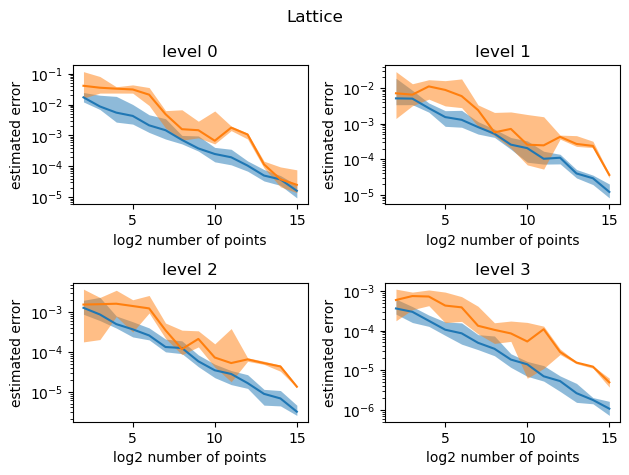

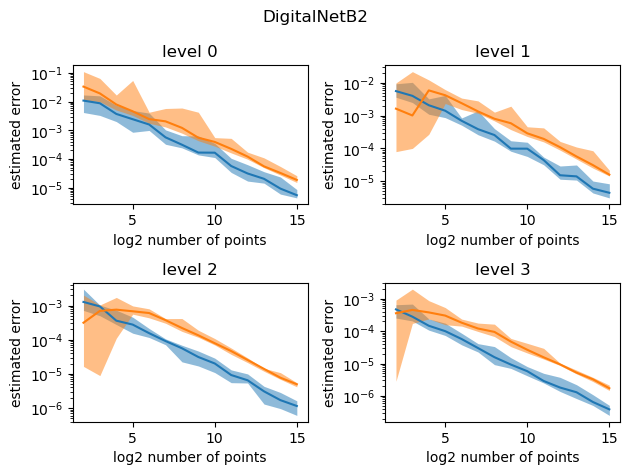

In [29]:
# Plot
qs = [0.05, 0.5, 0.99]
for discrete_distribution_type in discrete_distribution_types:
    discrete_distribution_str = stringify(discrete_distribution_type)
    
    _, axes = plt.subplots(2, 2)

    for level, ax in enumerate(axes.flatten()):

        for j, iterator_type in enumerate(iterator_types):
            iterator_str = stringify(iterator_type)
        
            errors = error_estimates[discrete_distribution_str, iterator_str, level]
            lower, mode, upper = np.quantile(errors, q=qs, axis=1)
            ax.fill_between(m_range, lower, upper, color=f"C{j}", alpha=0.5, linewidth=0)
            ax.plot(m_range, mode, color=f"C{j}", label=iterator_str)

        ax.set_title(f"level {level}")
        ax.set_yscale("log")
        # ax.legend(frameon=False)
        ax.set_xlabel("log2 number of points")
        ax.set_ylabel("estimated error")

    plt.suptitle(discrete_distribution_str)
    plt.tight_layout()